In [16]:
import netCDF4
import os
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

/home/jamesrunnalls/git/skin-temperature/venv/lib/python3.6/site-packages/ipykernel_launcher.py:12: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  if sys.path[0] == '':


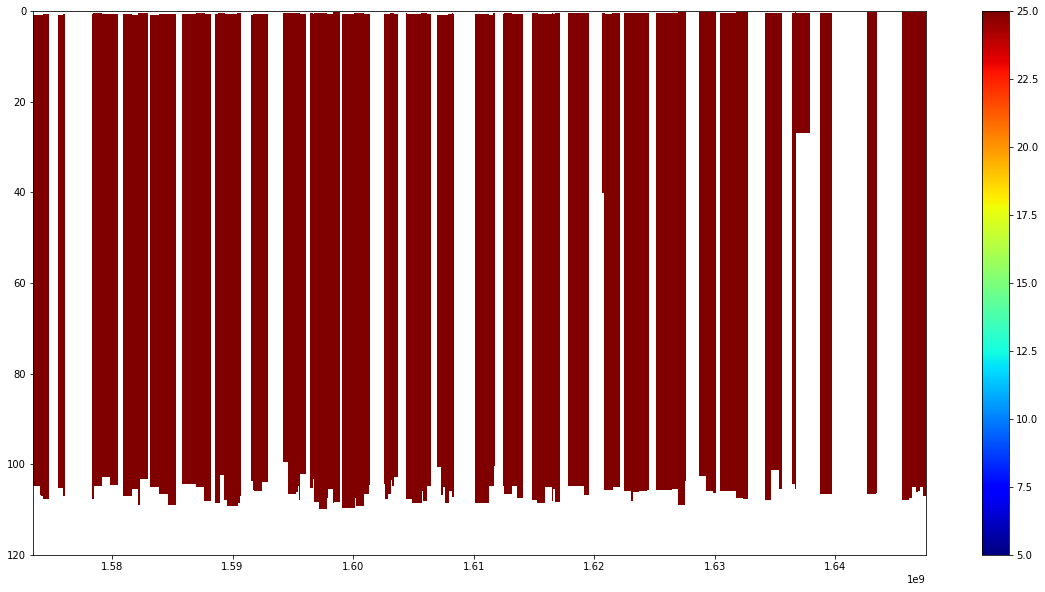

In [26]:
folder = "../data/Level2B"
files = os.listdir(folder)
files.sort()

fig,ax = plt.subplots(figsize=(20,10))
for file in files:
    nc = netCDF4.Dataset(os.path.join(folder, file), mode='r', format='NETCDF4_CLASSIC')
    z = nc.variables["prho"][:]
    t = nc.variables["time"][:]
    d = nc.variables["depth"][:]
    x,y = np.meshgrid(t, d)
    c = ax.pcolormesh(x,y,z,cmap='jet', vmin=5, vmax=25)
    nc.close()
ax.invert_yaxis()
fig.colorbar(c, ax=ax)

/home/jamesrunnalls/git/skin-temperature/venv/lib/python3.6/site-packages/ipykernel_launcher.py:20: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.


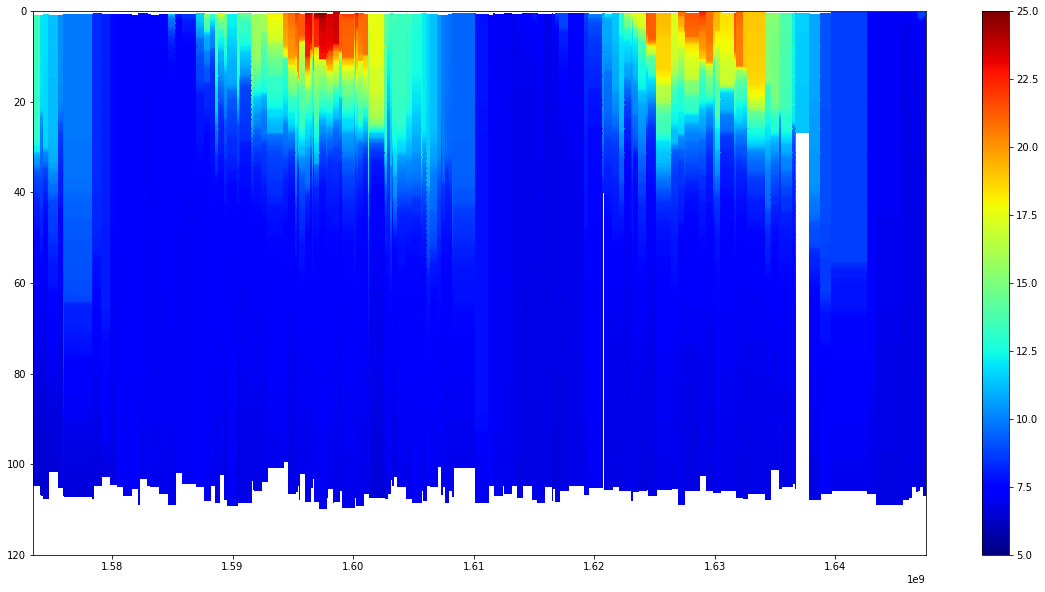

In [21]:
folder = "../data/Level2B"
files = os.listdir(folder)
files.sort()

fig,ax = plt.subplots(figsize=(20,10))
first = True
for file in files:
    nc = netCDF4.Dataset(os.path.join(folder, file), mode='r', format='NETCDF4_CLASSIC')
    if first:
        z = nc.variables["Temp"][:]
        t = nc.variables["time"][:] 
        d = nc.variables["depth"][:] 
        first = False
    else:
        z = np.concatenate((z, nc.variables["Temp"][:]), axis=1) 
        t = np.concatenate((t, nc.variables["time"][:]), axis=0) 
    nc.close()
    
x,y = np.meshgrid(t, d)
c = ax.pcolormesh(x,y,z,cmap='jet', vmin=5, vmax=25)
ax.invert_yaxis()
fig.colorbar(c, ax=ax)